Step 1: Import Required Libraries
First, ensure you have your environment set up and import the necessary modules.

In [1]:
import os
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from tensorflow.keras.utils import to_categorical
# Replace your VGG16 import with this:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

2026-06-19 06:23:40.799907: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781850220.993335      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781850221.051353      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781850221.509477      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781850221.509524      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781850221.509529      58 computation_placer.cc:177] computation placer alr

Step 2: Extract Image Features (The Encoder)
Instead of training a CNN from scratch, we use transfer learning with a pre-trained VGG16 model. We will remove the final classification layer so the model outputs a feature vector for the image instead of a class prediction.

In [2]:
BASE_DIR = '/kaggle/input/datasets/adityajn105/flickr8k'
IMAGES_DIR = os.path.join(BASE_DIR, 'Images')

# Load Pre-trained ResNet50 Model
base_model = ResNet50(weights='imagenet')
# Remove the final classification layer to get the feature map
model_encoder = Model(inputs=base_model.inputs, outputs=base_model.layers[-2].output)

features = {}
for img_name in tqdm(os.listdir(IMAGES_DIR)):
    img_path = os.path.join(IMAGES_DIR, img_name)
    
    # Load and preprocess image for ResNet50
    image = load_img(img_path, target_size=(224, 224))
    image = img_to_array(image)
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
    image = preprocess_input(image)
    
    # Extract feature representation
    feature = model_encoder.predict(image, verbose=0)
    image_id = img_name.split('.')[0]
    features[image_id] = feature

I0000 00:00:1781850236.040510      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781850236.046741      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


  0%|          | 0/8091 [00:00<?, ?it/s]

I0000 00:00:1781850241.612724     127 service.cc:152] XLA service 0x7edf700026f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781850241.612763     127 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781850241.612767     127 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781850242.440031     127 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781850245.199219     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Step 3: Load and Preprocess the Text Data
Flickr8k provides 5 captions per image. We need to clean these captions (remove punctuation, numbers, single letters) and add specific tokens (startseq and endseq) to tell our model where a sentence begins and ends.

In [3]:
import re

# Load captions file
with open(os.path.join(BASE_DIR, 'captions.txt'), 'r') as f:
    next(f) # Skip header
    captions_doc = f.read()

# Map image IDs to their corresponding list of captions
mapping = {}
for line in tqdm(captions_doc.split('\n')):
    tokens = line.split(',')
    if len(line) < 2:
        continue
    image_id, caption = tokens[0], tokens[1:]
    image_id = image_id.split('.')[0]
    caption = " ".join(caption)
    if image_id not in mapping:
        mapping[image_id] = []
    mapping[image_id].append(caption)

# Clean captions correctly using regex
for key, captions in mapping.items():
    for i in range(len(captions)):
        caption = captions[i].lower()
        
        # 👇 FIX: Properly strip punctuation and numbers using regex
        caption = re.sub(r'[^a-z\s]', '', caption)
        
        # 👇 FIX: Clean up consecutive white spaces 
        caption = re.sub(r'\s+', ' ', caption).strip()
        
        # Add start and end tokens, keeping words longer than 1 character
        caption = 'startseq ' + " ".join([word for word in caption.split() if len(word) > 1]) + ' endseq'
        captions[i] = caption

  0%|          | 0/40456 [00:00<?, ?it/s]

Step 4: Tokenization and Sequence Padding
We must convert our text words into numerical integers.

In [4]:
# Extract all captions into a single list
all_captions = [cap for caps in mapping.values() for cap in caps]

# Tokenize the text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1

# Find the maximum length of a caption for padding purposes
max_length = max(len(c.split()) for c in all_captions)

Step 5: Define the Data Generator
Image captioning datasets are too large to fit entirely into memory (RAM). We use a generator to yield data in batches. The model will expect three inputs/outputs per step:

Image feature vector

The current word sequence (input sequence)

The next word to predict (target word)

In [5]:
def data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size, batch_size):
    X1, X2, y = [], [], []
    n = 0
    while True:
        for key in data_keys:
            n += 1
            captions = mapping[key]
            # Get the image feature
            image_feature = features[key][0]
            
            for caption in captions:
                # Convert the caption to an integer sequence
                seq = tokenizer.texts_to_sequences([caption])[0]
                # Split sequence into multiple X, y pairs
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=max_length, padding='post')[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                    
                    X1.append(image_feature)
                    X2.append(in_seq)
                    y.append(out_seq)
            
            if n == batch_size:
                yield (np.array(X1), np.array(X2)), np.array(y)
                X1, X2, y = [], [], []
                n = 0

Step 6: Build the CNN-RNN Model (The Decoder)
Now we combine the image features and the text sequence inputs

In [6]:
# Image feature extractor model
inputs1 = Input(shape=(2048,))
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(512, activation='relu')(fe1)

# Sequence processor model
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.5)(se1)
se3 = LSTM(512)(se2)

# Decoder (combines both models)
decoder1 = add([fe2, se3])
decoder2 = Dense(512, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam')

# View the architecture
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 34, 256)   │  2,244,608 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 34, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 34)        │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 512)       │  1,574,912 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    262,656 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8768)      │  4,497,984 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,629,248 (36.73 MB)

 Trainable params: 9,629,248 (36.73 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Simple split: 90% train, 10% test
image_ids = list(mapping.keys())
split = int(len(image_ids) * 0.90)
train = image_ids[:split]
test = image_ids[split:]

# Training parameters
epochs = 30
batch_size = 32
steps = len(train) // batch_size

for i in range(epochs):
    # Create the data generator
    generator = data_generator(train, mapping, features, tokenizer, max_length, vocab_size, batch_size)
    # Fit for one epoch
    model.fit(generator, epochs=1, steps_per_epoch=steps, verbose=1)



227/227 ━━━━━━━━━━━━━━━━━━━━ 53s 215ms/step - loss: 5.0228
227/227 ━━━━━━━━━━━━━━━━━━━━ 49s 216ms/step - loss: 3.8439
227/227 ━━━━━━━━━━━━━━━━━━━━ 49s 214ms/step - loss: 3.4381
227/227 ━━━━━━━━━━━━━━━━━━━━ 48s 213ms/step - loss: 3.1686
227/227 ━━━━━━━━━━━━━━━━━━━━ 48s 213ms/step - loss: 2.9584
227/227 ━━━━━━━━━━━━━━━━━━━━ 49s 214ms/step - loss: 2.7962
227/227 ━━━━━━━━━━━━━━━━━━━━ 49s 214ms/step - loss: 2.6650
227/227 ━━━━━━━━━━━━━━━━━━━━ 48s 213ms/step - loss: 2.5662
227/227 ━━━━━━━━━━━━━━━━━━━━ 49s 214ms/step - loss: 2.4643
227/227 ━━━━━━━━━━━━━━━━━━━━ 48s 212ms/step - loss: 2.3914
227/227 ━━━━━━━━━━━━━━━━━━━━ 48s 211ms/step - loss: 2.3109
227/227 ━━━━━━━━━━━━━━━━━━━━ 49s 214ms/step - loss: 2.2499
227/227 ━━━━━━━━━━━━━━━━━━━━ 49s 215ms/step - loss: 2.1905
227/227 ━━━━━━━━━━━━━━━━━━━━ 49s 215ms/step - loss: 2.1311
227/227 ━━━━━━━━━━━━━━━━━━━━ 48s 213ms/step - loss: 2.0810
227/227 ━━━━━━━━━━━━━━━━━━━━ 49s 214ms/step - loss: 2.0274
227/227 ━━━━━━━━━━━━━━━━━━━━ 48s 213ms/step - loss: 1.98

Step 7: Train the Model
Split your dataset into train/test, and start the training process.

In [8]:
# Save the weights after training
model.save('upd2_best_model.h5')

Step 8: Inference (Generating Captions)
To generate a caption for a new image, we extract its VGG16 features, feed the startseq token into the model, and recursively predict the next word until we hit endseq.

In [9]:
def idx_to_word(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def predict_caption(model, image_feature, tokenizer, max_length):
    in_text = 'startseq'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')
        yhat = model.predict([image_feature, sequence], verbose=0)[0]
        
        # Sort word indices by probability from highest to lowest
        sorted_indices = np.argsort(yhat)[::-1]
        
        chosen_word = None
        words_so_far = in_text.split()
        
        for idx in sorted_indices:
            word = idx_to_word(idx, tokenizer)
            if word is None:
                continue
            
            # Anti-loop check: If the word was used recently and creates a loop, skip it
            if len(words_so_far) >= 3 and word in words_so_far[-3:]:
                if words_so_far[-1] == word or (words_so_far[-2] == words_so_far[-1]):
                    continue 
                    
            chosen_word = word
            break
            
        if chosen_word is None or chosen_word == 'endseq':
            break
            
        in_text += " " + chosen_word
    return in_text

Step 9: Evaluate Model Performance (BLEU Score)

In [10]:
from nltk.translate.bleu_score import corpus_bleu

actual, predicted = list(), list()

# Iterate over the test dataset split to generate predictions
for key in tqdm(test):
    # 1. Get and clean ground truth captions for this image
    captions = mapping[key]
    references = [caption.replace('startseq ', '').replace(' endseq', '').split() for caption in captions]
    actual.append(references)
    
    # 2. Predict caption using the trained model
    pred_caption = predict_caption(model, features[key], tokenizer, max_length)
    pred_words = pred_caption.replace('startseq ', '').replace(' endseq', '').split()
    predicted.append(pred_words)

# 3. Calculate BLEU scores
print("BLEU-1 (Individual 1-gram): %f" % corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))
print("BLEU-2 (Bi-gram): %f" % corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))

  0%|          | 0/810 [00:00<?, ?it/s]

BLEU-1 (Individual 1-gram): 0.433172
BLEU-2 (Bi-gram): 0.253228


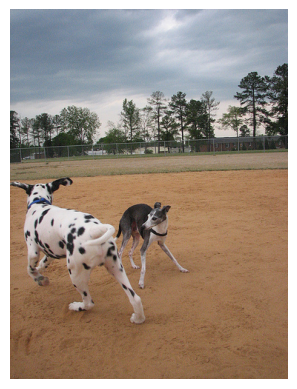

IMAGE ID: 486720042_b785e7f88c
PREDICTED CAPTION: 
-> Two dogs on the beach

ACTUAL GROUND-TRUTH CAPTIONS:
   1. Black and white spotted dog is circling gray and white dog
   2. Spotted dog playing on baseball field with another dog
   3. Two dogs are running around each other in the sand
   4. Two dogs play in sandy field
   5. Two dogs play on baseball field


In [18]:
import random

# 1. Pick a random image ID from your test set
random_image_id = random.choice(test)

# 2. Get the full path to the image file to display it
# Note: Reconstructing the filename with '.jpg' based on Step 2 setup
image_file_name = random_image_id + '.jpg'
image_path = os.path.join(IMAGES_DIR, image_file_name)

# 3. Extract the pre-computed feature for this specific image
image_feature = features[random_image_id]

# 4. Generate the prediction using your updated inference function
predicted_caption = predict_caption(model, image_feature, tokenizer, max_length)

# Clean up tokens for clean rendering
cleaned_prediction = predicted_caption.replace('startseq', '').replace('endseq', '').strip()

# 5. Retrieve the original actual captions for reference comparison
actual_captions = [cap.replace('startseq ', '').replace(' endseq', '').strip() for cap in mapping[random_image_id]]

# 6. Plot and display the image alongside the results
img = load_img(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()

print("="*60)
print(f"IMAGE ID: {random_image_id}")
print(f"PREDICTED CAPTION: \n-> {cleaned_prediction.capitalize()}")
print("\nACTUAL GROUND-TRUTH CAPTIONS:")
for i, caption in enumerate(actual_captions, 1):
    print(f"   {i}. {caption.capitalize()}")
print("="*60)